In [40]:
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [15]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

4422102/4422102 [==============================] - 1s 0us/step


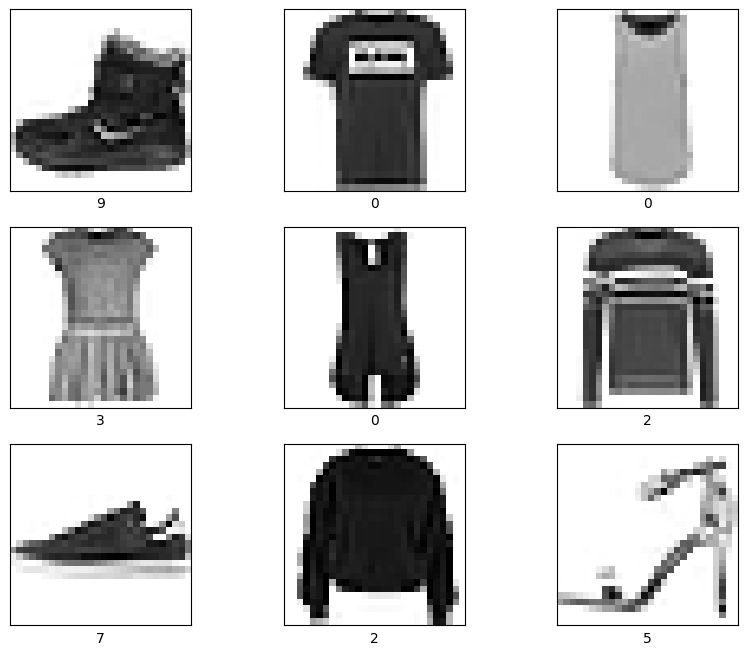

In [45]:
plt.figure(figsize=(10,8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train[i], cmap="binary")
    plt.xlabel(y_train[i])
plt.show()

In [ ]:
model = keras.models.Sequential()

model.add(keras.layers.Reshape((28,28,1), input_shape=(28,28)))
model.add(keras.layers.Conv2D(32, (3,3), activation="relu"))
model.add(keras.layers.MaxPooling2D((2,2)))
model.add(keras.layers.Conv2D(64, (3,3), activation="relu"))
model.add(keras.layers.MaxPooling2D((2,2)))
model.add(keras.layers.Conv2D(64, (2,2), activation="relu"))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(64, activation="relu"))
model.add(keras.layers.Dense(10, activation="softmax"))

model.summary()


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape_1 (Reshape)         (None, 28, 28, 1)         0         
                                                                 
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 4, 4, 64)        

In [35]:
model.compile(optimizer="adam", loss=keras.losses.sparse_categorical_crossentropy, metrics=["accuracy"])

In [36]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10


1875/1875 [==============================] - 33s 17ms/step - loss: 0.5313 - accuracy: 0.8230 - val_loss: 0.3928 - val_accuracy: 0.8599
Epoch 2/10
1875/1875 [==============================] - 39s 21ms/step - loss: 0.3402 - accuracy: 0.8752 - val_loss: 0.3682 - val_accuracy: 0.8675
Epoch 3/10
1875/1875 [==============================] - 31s 17ms/step - loss: 0.3018 - accuracy: 0.8889 - val_loss: 0.3607 - val_accuracy: 0.8696
Epoch 4/10
1875/1875 [==============================] - 36s 19ms/step - loss: 0.2794 - accuracy: 0.8957 - val_loss: 0.3266 - val_accuracy: 0.8835
Epoch 5/10
1875/1875 [==============================] - 40s 22ms/step - loss: 0.2611 - accuracy: 0.9026 - val_loss: 0.3249 - val_accuracy: 0.8838
Epoch 6/10
1875/1875 [==============================] - 37s 20ms/step - loss: 0.2442 - accuracy: 0.9091 - val_loss: 0.3032 - val_accuracy: 0.8952
Epoch 7/10
1875/1875 [==============================] - 28s 15ms/step - loss: 0.2284 - accuracy: 0.9144 - val_loss: 0.3329

In [38]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"{loss=}")
print(f"{accuracy=}")

313/313 [==============================] - 2s 6ms/step - loss: 0.3225 - accuracy: 0.8981
loss=0.3224978744983673
accuracy=0.8981000185012817


In [42]:
new_data = X_test[:1]
predicted = model.predict(new_data)
print(f"Predicted: {np.argmax(predicted[0])}")
print(f"Actual: {y_test[0]}")

1/1 [==============================] - 0s 40ms/step
Predicted: 9
Actual: 9
